<a href="https://colab.research.google.com/github/Varsha7781/Deep-Learning/blob/main/YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Yolo 26**

**Group members**

Varsharani Lad (202301040104)

Snehal Chavan

Pournima Khamble

Neha Narkhede

GitHub Link :

**DATASET**

The dataset consists of 8479 images containing six fruit classes: Apple, Grapes, Pineapple, Orange, Banana, and Watermelon.
The dataset is pre-annotated in YOLOv8 format, eliminating the need for manual annotation.
Images were resized to 640×640 and augmented using horizontal flipping with a probability of 50% to improve model generalization.

**Install Libraries**

In [6]:
!pip install ultralytics matplotlib opencv-python kagglehub

**Download Dataset**

In [7]:
import kagglehub

path = kagglehub.dataset_download("lakshaytyagi01/fruit-detection")

print("Dataset path:", path)

100%|██████████| 501M/501M [00:05<00:00, 90.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1


Check Structure

In [8]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/images
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/labels
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/train
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/train/images
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/train/labels
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/valid
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/valid/images
/root/.cache/kagglehub/data

In [9]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".yaml"):
            print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/data.yaml


In [10]:
yaml_path = "/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/data.yaml"

with open(yaml_path, 'r') as f:
    print(f.read())

names:
- Apple
- Banana
- Grape
- Orange
- Pineapple
- Watermelon
nc: 6
test: E:\DL\attempt1\attempt3\datasets\Fruits-detection-1\test\images
train: E:\DL\attempt1\attempt3\datasets\Fruits-detection-1\train\images
val: E:\DL\attempt1\attempt3\datasets\Fruits-detection-1\valid\images



In [11]:
yaml_path = "/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/data.yaml"

fixed_yaml = """
train: train/images
val: valid/images
test: test/images

nc: 6
names: ['Apple', 'Banana', 'Grape', 'Orange', 'Pineapple', 'Watermelon']
"""

with open(yaml_path, 'w') as f:
    f.write(fixed_yaml)

print("✅ YAML fixed successfully!")

✅ YAML fixed successfully!


In [12]:
!ls /root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/

cli.log  data.yaml  README.txt	test  train  valid  yolov8s.pt


In [13]:
yaml_path = "/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/data.yaml"

fixed_yaml = """
train: train/images
val: valid/images
test: test/images

nc: 6
names: ['Apple', 'Banana', 'Grape', 'Orange', 'Pineapple', 'Watermelon']
"""

with open(yaml_path, 'w') as f:
    f.write(fixed_yaml)

print("✅ YAML final fix done")

✅ YAML final fix done


In [14]:
!pip install ultralytics

In [15]:
yaml_path = "/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/data.yaml"

**Train YOLOv8 Model**

In [17]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data=yaml_path,
    epochs=5,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optim

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a7d03e4a7e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

**VISUALIZATION**

Detection Output

In [25]:
new_path = path + "/Fruits-detection"

import os
print(os.listdir(new_path))

['yolov8s.pt', 'test', 'train', 'README.txt', 'data.yaml', 'valid', 'cli.log']


In [26]:
print(os.listdir(new_path + "/test"))

['images', 'labels']


In [27]:
print(os.listdir(new_path + "/test/images"))

['6c4e9a1311a28275_jpg.rf.4e865fab57e98ad2d204b0ffef99111e.jpg', '540d26ebc8b9a1cb_jpg.rf.696c22914adb04724a2ec9828b8c4ebe.jpg', '0113f90219ef40da_jpg.rf.b0c40161be08c4532f372d07a968e2ee.jpg', 'e2567dd988ce6fff_jpg.rf.599d5fe80758f0051551b1db4488d8cf.jpg', 'e92a5061e1ac75fe_jpg.rf.6d5b26bf04da912f3bc7884f2205c92e.jpg', '58ee99d76e806696_jpg.rf.91e4603c81e15f5793c4a8dcb4c575d4.jpg', 'eedaef00d5cfe149_jpg.rf.0cfec1cf54f7a23b144a61d38040866f.jpg', '533563a9ff6cf2e6_jpg.rf.717336863275c8393c525fb683723855.jpg', '006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430.jpg', '0b3153219ce8a7cd_jpg.rf.18e987de0383ef6a881515ea82685d5e.jpg', '2f2112e171a01d43_jpg.rf.6744a19ae5b8354ce307498dc5d8860c.jpg', 'edb2b64caa9d7d98_jpg.rf.141acbe8eece46bbd302a6aacdaf0076.jpg', 'a30d502fade25820_jpg.rf.e29f9b5791e0b07c25e95b792001c86e.jpg', '028ee4d4f435c506_jpg.rf.8f171ec7a2bb200c074e87bb494682bd.jpg', '9cbfacd061df0cb7_jpg.rf.2668ed3e2f1969feacdaa4bd2eca7b91.jpg', 'a11b777f7cacfaa7_jpg.rf.ae42662781cd19

In [29]:
images = os.listdir(new_path + "/test/images")
print(len(images))

457


In [30]:
print(images[:10])

['6c4e9a1311a28275_jpg.rf.4e865fab57e98ad2d204b0ffef99111e.jpg', '540d26ebc8b9a1cb_jpg.rf.696c22914adb04724a2ec9828b8c4ebe.jpg', '0113f90219ef40da_jpg.rf.b0c40161be08c4532f372d07a968e2ee.jpg', 'e2567dd988ce6fff_jpg.rf.599d5fe80758f0051551b1db4488d8cf.jpg', 'e92a5061e1ac75fe_jpg.rf.6d5b26bf04da912f3bc7884f2205c92e.jpg', '58ee99d76e806696_jpg.rf.91e4603c81e15f5793c4a8dcb4c575d4.jpg', 'eedaef00d5cfe149_jpg.rf.0cfec1cf54f7a23b144a61d38040866f.jpg', '533563a9ff6cf2e6_jpg.rf.717336863275c8393c525fb683723855.jpg', '006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430.jpg', '0b3153219ce8a7cd_jpg.rf.18e987de0383ef6a881515ea82685d5e.jpg']


In [31]:
for img in images:
    print(img)

6c4e9a1311a28275_jpg.rf.4e865fab57e98ad2d204b0ffef99111e.jpg
540d26ebc8b9a1cb_jpg.rf.696c22914adb04724a2ec9828b8c4ebe.jpg
0113f90219ef40da_jpg.rf.b0c40161be08c4532f372d07a968e2ee.jpg
e2567dd988ce6fff_jpg.rf.599d5fe80758f0051551b1db4488d8cf.jpg
e92a5061e1ac75fe_jpg.rf.6d5b26bf04da912f3bc7884f2205c92e.jpg
58ee99d76e806696_jpg.rf.91e4603c81e15f5793c4a8dcb4c575d4.jpg
eedaef00d5cfe149_jpg.rf.0cfec1cf54f7a23b144a61d38040866f.jpg
533563a9ff6cf2e6_jpg.rf.717336863275c8393c525fb683723855.jpg
006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430.jpg
0b3153219ce8a7cd_jpg.rf.18e987de0383ef6a881515ea82685d5e.jpg
2f2112e171a01d43_jpg.rf.6744a19ae5b8354ce307498dc5d8860c.jpg
edb2b64caa9d7d98_jpg.rf.141acbe8eece46bbd302a6aacdaf0076.jpg
a30d502fade25820_jpg.rf.e29f9b5791e0b07c25e95b792001c86e.jpg
028ee4d4f435c506_jpg.rf.8f171ec7a2bb200c074e87bb494682bd.jpg
9cbfacd061df0cb7_jpg.rf.2668ed3e2f1969feacdaa4bd2eca7b91.jpg
a11b777f7cacfaa7_jpg.rf.ae42662781cd1966c813d0334dc2d0f9.jpg
3d90bc08004f54a7_jpg.rf.

In [32]:
for img in images:
    full_path = new_path + "/test/images/" + img
    print(full_path)

/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/images/6c4e9a1311a28275_jpg.rf.4e865fab57e98ad2d204b0ffef99111e.jpg
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/images/540d26ebc8b9a1cb_jpg.rf.696c22914adb04724a2ec9828b8c4ebe.jpg
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/images/0113f90219ef40da_jpg.rf.b0c40161be08c4532f372d07a968e2ee.jpg
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/images/e2567dd988ce6fff_jpg.rf.599d5fe80758f0051551b1db4488d8cf.jpg
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/images/e92a5061e1ac75fe_jpg.rf.6d5b26bf04da912f3bc7884f2205c92e.jpg
/root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/images/58ee99d76e806696_jpg.rf.91e4603c81e15f5793c4a8dcb4c575d4.jpg
/root/.cache/kag

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

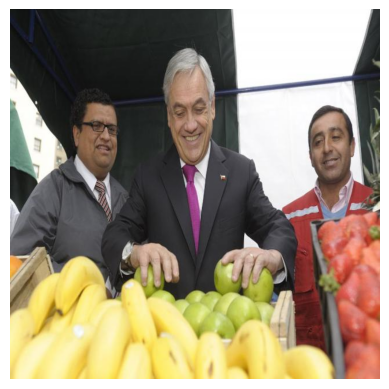

In [33]:
import cv2
import matplotlib.pyplot as plt

img_path = new_path + "/test/images/" + images[0]
img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

Testing on: 0f667f6f87ee44d6_jpg.rf.c76742978aaf7b366ecac63035c2523b.jpg

image 1/1 /root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/test/images/0f667f6f87ee44d6_jpg.rf.c76742978aaf7b366ecac63035c2523b.jpg: 640x640 1 Apple, 8.9ms
Speed: 2.2ms preprocess, 8.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


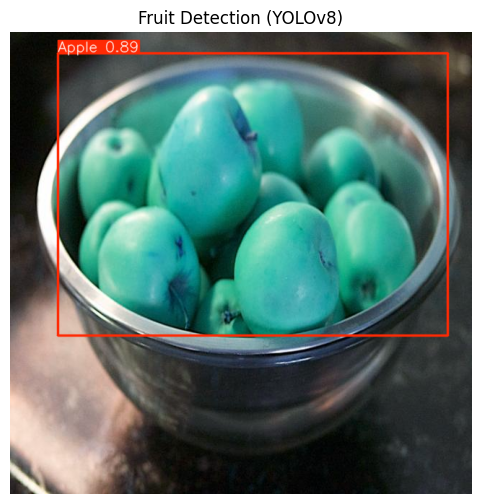

In [34]:
import os
import random

images = os.listdir(new_path + "/test/images")
img_name = random.choice(images)

img_path = new_path + "/test/images/" + img_name
print("Testing on:", img_name)

results = model(img_path)

import matplotlib.pyplot as plt

for r in results:
    plt.figure(figsize=(10,6))
    plt.imshow(r.plot())
    plt.axis('off')
    plt.title("Fruit Detection (YOLOv8)")
    plt.show()

Multi-Object Classification Output

In [35]:
for r in results:
    for box in r.boxes:
        class_id = int(box.cls)
        confidence = float(box.conf)

        print(f"{model.names[class_id]} → {confidence:.2f}")

Apple → 0.89


**TRAINING GRAPHS**

In [37]:
import os
import pandas as pd

base_path = "runs/detect"

folders = sorted(os.listdir(base_path))
latest_folder = folders[-1]

print("Using folder:", latest_folder)

metrics = pd.read_csv(f"{base_path}/{latest_folder}/results.csv")

Using folder: train3


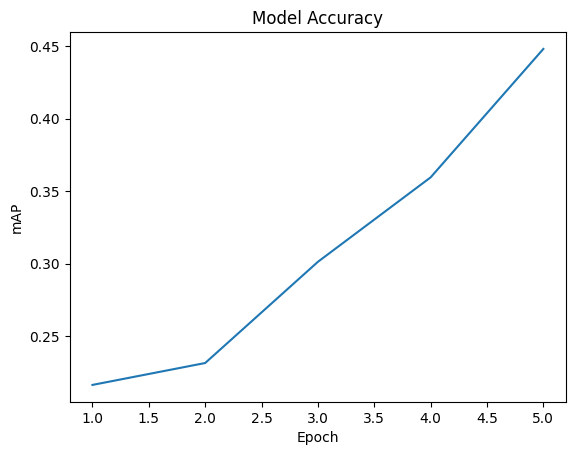

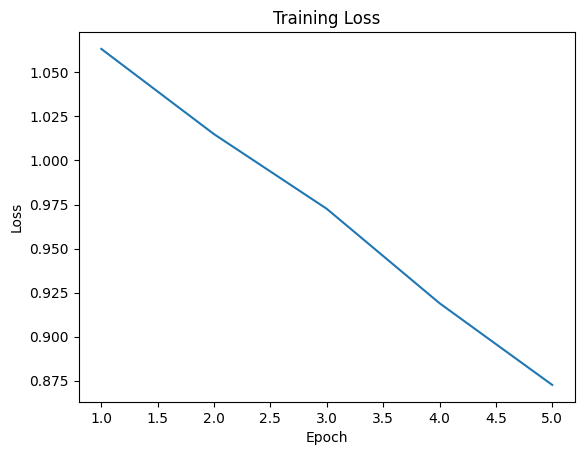

In [38]:
import matplotlib.pyplot as plt

# mAP Graph
plt.figure()
plt.plot(metrics['epoch'], metrics['metrics/mAP50(B)'])
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('Model Accuracy')
plt.show()

# Loss Graph
plt.figure()
plt.plot(metrics['epoch'], metrics['train/box_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [45]:
path = path + "/Fruits-detection"

In [46]:
import os

print(os.listdir(path))

['yolov8s.pt', 'test', 'train', 'README.txt', 'data.yaml', 'valid', 'cli.log']


Images: ['d490b9299927a6e2_jpg.rf.d41488550068480ae4ee86e9d5cc1047.jpg', 'eae0df3e94c3a7ff_jpg.rf.c15260e41d50f007910b7c5465c20cc2.jpg', '119d422cc10bb3db_jpg.rf.7fed195bf50ee0903a4a4eed56274642.jpg', '82c9657b3d301836_jpg.rf.391e6645ad32b84f97bb96fa76bfa407.jpg', 'feb546bb21cec831_jpg.rf.0d5990bfc8b9d9d7380ddd7140cfaa68.jpg']
Using image: /root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/valid/images/d490b9299927a6e2_jpg.rf.d41488550068480ae4ee86e9d5cc1047.jpg

image 1/1 /root/.cache/kagglehub/datasets/lakshaytyagi01/fruit-detection/versions/1/Fruits-detection/valid/images/d490b9299927a6e2_jpg.rf.d41488550068480ae4ee86e9d5cc1047.jpg: 640x640 1 apple, 11.5ms
Speed: 1.9ms preprocess, 11.5ms inference, 11.1ms postprocess per image at shape (1, 3, 640, 640)


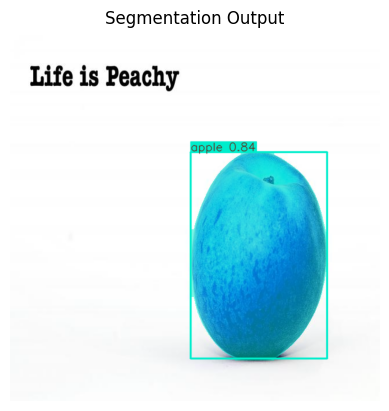

In [47]:
import os
import matplotlib.pyplot as plt

# Correct folder
img_folder = path + "/valid/images"

# Check images
print("Images:", os.listdir(img_folder)[:5])  # show few files

# Pick one image
img_name = os.listdir(img_folder)[0]
img_path = os.path.join(img_folder, img_name)

print("Using image:", img_path)

# Run segmentation
seg_results = seg_model(img_path)

for r in seg_results:
    plt.imshow(r.plot())
    plt.axis('off')
    plt.title("Segmentation Output")
    plt.show()